In [1]:
import numpy as np
import sklearn as sk
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt


## Theoretical questions answers
- 3.1: There might be conditional independence even if features are correlated or dependent.
- 3.2: Accuracy does not take into account how "sure" model is on its prediction, also it may not take into account class imbalance and in such scenario we may want to just classify for the majority class with very low threshold on probability.  Logarithmic loss metric is better suited to the problem, as it measures uncertainity of model predictions and penalizes for predictions with low confidence
- 3.3: The matrix becomes singular and therefore cannot be inverted
- 3.4: The model combining the LDA (covariance matrices for all classes are the same) and NB assumptions would be a Gaussian NB but all features would be assumed to have a normal distribution with the same variance.

In [14]:
class LDA:
    def __init__(self):
        pass
    def fit(self,X,y):
        self.prior=np.sum(y)/len(y)
        mask=np.array(y).astype(bool)
        positive=X[mask]
        negative=X[~mask]
        self.m1=np.mean(positive, axis=0)
        self.m0=np.mean(negative, axis=0)
        self.Sigma = (1 / (len(y) - 2)) * (
    (positive - self.m1).T @ (positive - self.m1) +
    (negative - self.m0).T @ (negative - self.m0)
)
        return self
    def predict_proba(self,X_test):
        det=np.linalg.det(self.Sigma)
        inverse_sigma=np.linalg.inv(self.Sigma)
        cond1=(((2*np.pi)**((-1)*X_test.shape[1]/2))*(det**(-1/2))*np.exp(-0.5*np.einsum('ij,jk,ik->i', (X_test - self.m1), inverse_sigma, (X_test - self.m1))))

        cond0=(((2*np.pi)**((-1)*X_test.shape[1]/2))*(det**(-1/2))*np.exp(-0.5*np.einsum('ij,jk,ik->i', (X_test - self.m0), inverse_sigma, (X_test - self.m0))))

        post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
        return post
    def predict(self,X_test):
        post=self.predict_proba(X_test)
        classes=(post>0.5).astype(int)
        return classes
    def get_params(self):
        return self.m1,self.m0,self.Sigma,self.prior


In [15]:
class QDA:
    def fit(self,X,y):
        self.prior=np.sum(y)/len(y)
        mask=np.array(y).astype(bool)
        positive=X[mask]
        negative=X[~mask]
        self.m1=np.mean(positive, axis=0)
        self.m0=np.mean(negative, axis=0)
        self.Sigma1=np.cov(positive, rowvar=False)
        self.Sigma0=np.cov(negative, rowvar=False)
        return self
    def predict_proba(self,X_test):
        det1=np.linalg.det(self.Sigma1)
        inverse_sigma1=np.linalg.inv(self.Sigma1)
        det0=np.linalg.det(self.Sigma0)
        inverse_sigma0=np.linalg.inv(self.Sigma0)
        cond1=(((2*np.pi)**((-1)*X_test.shape[1]/2))*(det1**(-1/2))*np.exp(-0.5*np.einsum('ij,jk,ik->i', (X_test - self.m1), inverse_sigma1, (X_test - self.m1))))

        cond0=(((2*np.pi)**((-1)*X_test.shape[1]/2))*(det0**(-1/2))*np.exp(-0.5*np.einsum('ij,jk,ik->i', (X_test - self.m0), inverse_sigma0, (X_test - self.m0))))

        post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
        post=np.array(post)
        return post
    def predict(self,X_test):
        post=self.predict_proba(X_test)
        classes=(post>0.5).astype(int)
        return classes
    def get_params(self):
        return self.m1,self.m0,self.Sigma1,self.Sigma0,self.prior

In [16]:
class NB:
    """
    Naive Bayes Gaussian binary classifier. self.m1 contains estimated means for x1,x2,.. for positive class, self.m0 for negative class, self.vars1 contains estimated variations for x1,x2,.. for positive, self.vars0 for negative.
    """
    def fit(self,X,y):
        self.prior=np.mean(y)
        mask=np.array(y).astype(bool)
        positive=X[mask]
        negative=X[~mask]
        self.m1 = positive.mean(axis=0).tolist()
        self.vars1 = positive.var(axis=0).tolist()
        self.m0=negative.mean(axis=0).tolist()
        self.vars0=negative.var(axis=0).tolist()
        return self
    def predict_proba(self,X_test):
        c0=[0 for i in range(len(X_test))]
        c1=[0 for i in range(len(X_test))]
        for i in range(len(X_test)):
            posprod=1
            negprod=1
            for j in range(len(X_test[0])):
                posprod=posprod*simulation_set_creator.gaussian(X_test[i][j],self.m1[j],self.vars1[j])
                negprod=negprod*simulation_set_creator.gaussian(X_test[i][j],self.m0[j],self.vars0[j])
            c0[i]=(1-self.prior)*negprod
            c1[i]=self.prior*posprod
        c0=np.array(c0)
        c1=np.array(c1)
        return c1/(c1+c0)
    def predict(self,X_test):
        post=self.predict_proba(X_test)
        classes=(post>0.5).astype(int)
        return classes
    def get_params(self):
        return self.prior,self.m1,self.m0,self.vars1,self.vars0

In [17]:
class simulation_set_creator:
    """
    I assume that n parameter describes the whole datasets size (i.e record count). The class is a container for static methods used for generating sets for experiments,as well as some other auxilliary methods.
    """
    @staticmethod
    def generate_2d_normal(n,means,vars,rho):
        cov = np.array([[vars[0], rho],
                        [rho, vars[1]]])
        X = np.random.multivariate_normal(means, cov, size=n)
        return X
    @staticmethod
    def create_schema1(n,p,a):
        """
        Method creates dataset as described in lab 1 schema 1, n- obs. number, p- feature number, a -mean in class 1.
        """
        protomask=np.random.binomial(1,0.5,n)
        mask=protomask.astype(bool)
        data = np.zeros((n, p+1))
        for i in range(p):
            class0=np.random.normal(0,1,n)
            class1=np.random.normal(a,1,n)
            data[:, i] = np.where(mask, class0, class1)
        data[:,p]=protomask.astype(int)
        return data
    @staticmethod
    def create_schema2(n,p,a,rho):
        """
        Method creates dataset as described in lab 1 schema 1, n- obs. number, p=2- feature number,rho-abs corr. between features, a -mean in class 1. The multidimensional distribution is to be 2 dimensional. if p is not 2 then columns [2:-1] will be 0 in case p>2
        """
        protomask=np.random.binomial(1,0.5,n)
        mask=protomask.astype(bool)
        data = np.zeros((n, p+1))
        vars=[1,1]
        class0=simulation_set_creator.generate_2d_normal(n,[0,0],vars,rho)
        class1=simulation_set_creator.generate_2d_normal(n,[a,a],vars,-rho)
        data[:, 0:2] = np.where(mask.reshape(-1, 1), class0, class1)
        # data[:, 0:2] = np.where(mask, class0, class1)
        data[:,-1]=protomask.astype(int)
        return data
    @staticmethod
    def create_method(name):
        if name=="QDA":
            return QDA()
        if name=="LDA":
            return LDA()
        if name=="NB":
            return NB()
    @staticmethod
    def gaussian(x, mean, var):
        return (1 / np.sqrt(2 * np.pi * var)) * np.exp(-0.5 * ((x - mean) ** 2) / var)


In [52]:
def experiment_pipeline(schema,fixed_param,fixed_param_value,changing_param,changing_param_values,filename):
    """
    This function runs a single experiment (i.e for one set of params and specified changing param), providing one boxplot. Then pdf versions of boxplots from different experiments where merged with code not provided here, as it is out of scope of the lab task.
    """
    a_values=changing_param_values

    accuracy_scores={
        "LDA":{key: [] for key in a_values},
        "QDA":{key: [] for key in a_values},
        "NB":{key: [] for key in a_values}
    }
    methods=["LDA","QDA","NB"]
    seeds=np.random.randint(1,1000000,30)
    for a in a_values:
        if fixed_param=="a":
            if schema==1:
                data=simulation_set_creator.create_schema1(1000,2,fixed_param_value)
            else:
                data=simulation_set_creator.create_schema2(1000,2,fixed_param_value,a)
        elif fixed_param=="rho":
            if schema==1:
                data=simulation_set_creator.create_schema1(1000,2,a)
            else:
                data=simulation_set_creator.create_schema2(1000,2,a,fixed_param_value)
        for seed in seeds:
            X=data[:,:-1]
            y=data[:,-1]
            x_train,x_test,y_train,y_test = train_test_split(
                X, y,
                test_size=0.3,
                random_state=seed,
            )
            for m in methods:
                own=simulation_set_creator.create_method(m)
                own.fit(x_train, y_train)
                y_test_hat=own.predict(x_test)
                accuracy_scores[m][a].append(accuracy_score(y_test, y_test_hat))
    # --- Plotting ---
        classifiers = list(accuracy_scores.keys())
        n_groups = len(a_values)
        n_classifiers = len(classifiers)

        fig, ax = plt.subplots(figsize=(14, 6))

        box_width = 0.2
        group_spacing = 1.0
        colors = ["#4C72B0", "#DD8452", "#55A868"]

        for i, (clf, color) in enumerate(zip(classifiers, colors)):
            positions = [j * group_spacing + (i - n_classifiers / 2 + 0.5) * box_width for j in range(n_groups)]
            data = [accuracy_scores[clf][key] for key in a_values]

            bp = ax.boxplot(data, positions=positions, widths=box_width * 0.9,
                            patch_artist=True, manage_ticks=False,
                            boxprops=dict(facecolor=color, alpha=0.7),
                            medianprops=dict(color="black", linewidth=2),
                            whiskerprops=dict(color=color),
                            capprops=dict(color=color),
                            flierprops=dict(marker='o', color=color, alpha=0.5))

            ax.plot([], [], color=color, linewidth=6, alpha=0.7, label=clf)

        group_centers = [j * group_spacing for j in range(n_groups)]
        ax.set_xticks(group_centers)
        ax.set_xticklabels([str(v) for v in a_values], fontsize=12)

        ax.set_xlabel(f"{changing_param} values", fontsize=13)
        ax.set_ylabel("Accuracy", fontsize=13)
        ax.set_title(f"Accuracy by Value of {changing_param} and Classifier, data from schema {schema}", fontsize=15)
        ax.legend(title="Classifier", fontsize=11, title_fontsize=12)
        ax.set_ylim(0.35, 1.02)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.savefig(f"C:\\Users\\andrz\\Documents\\{filename}.pdf", dpi=150)
        plt.show()

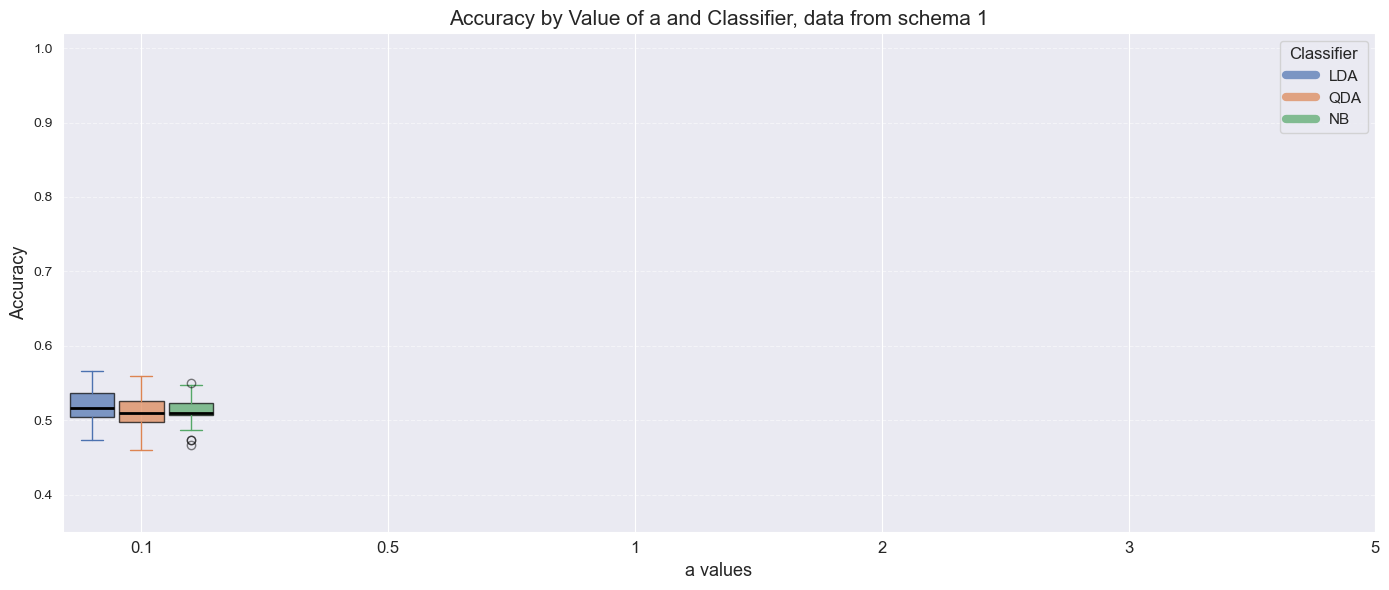

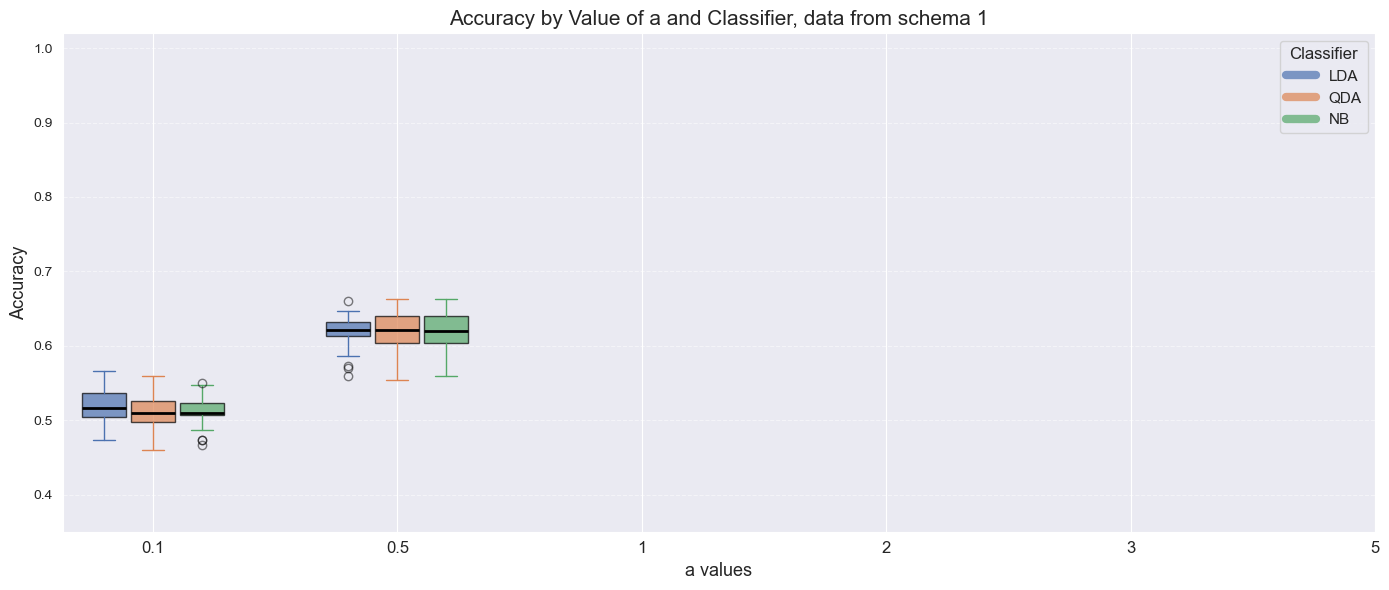

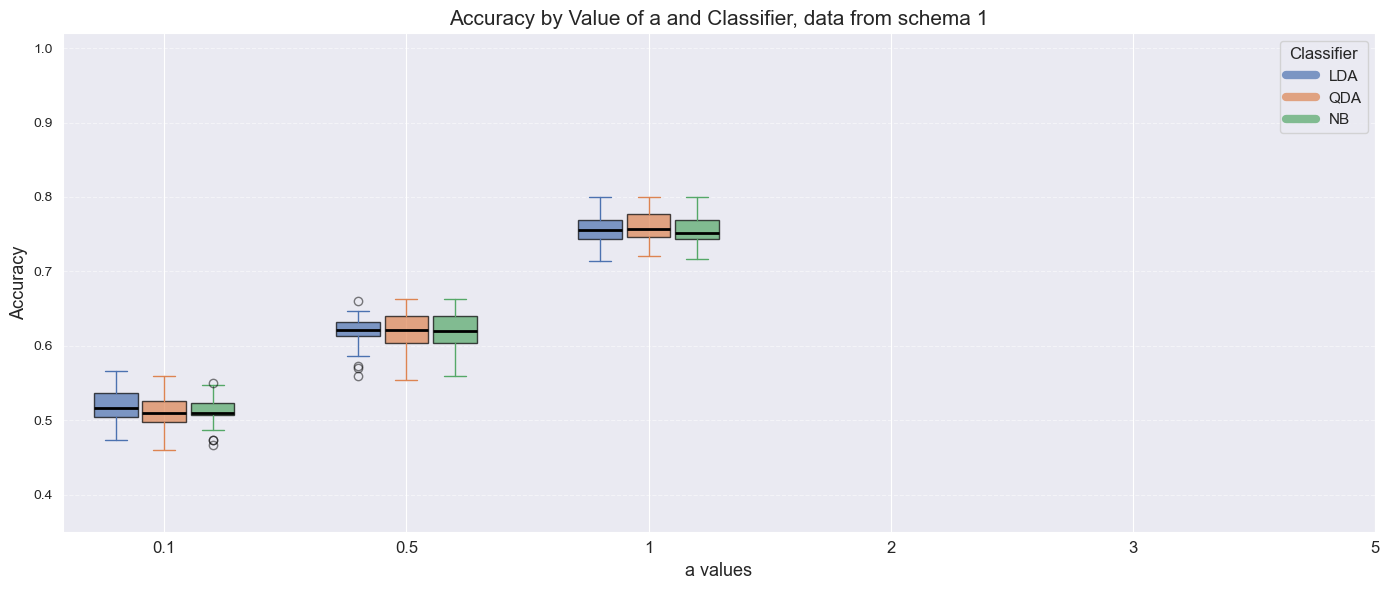

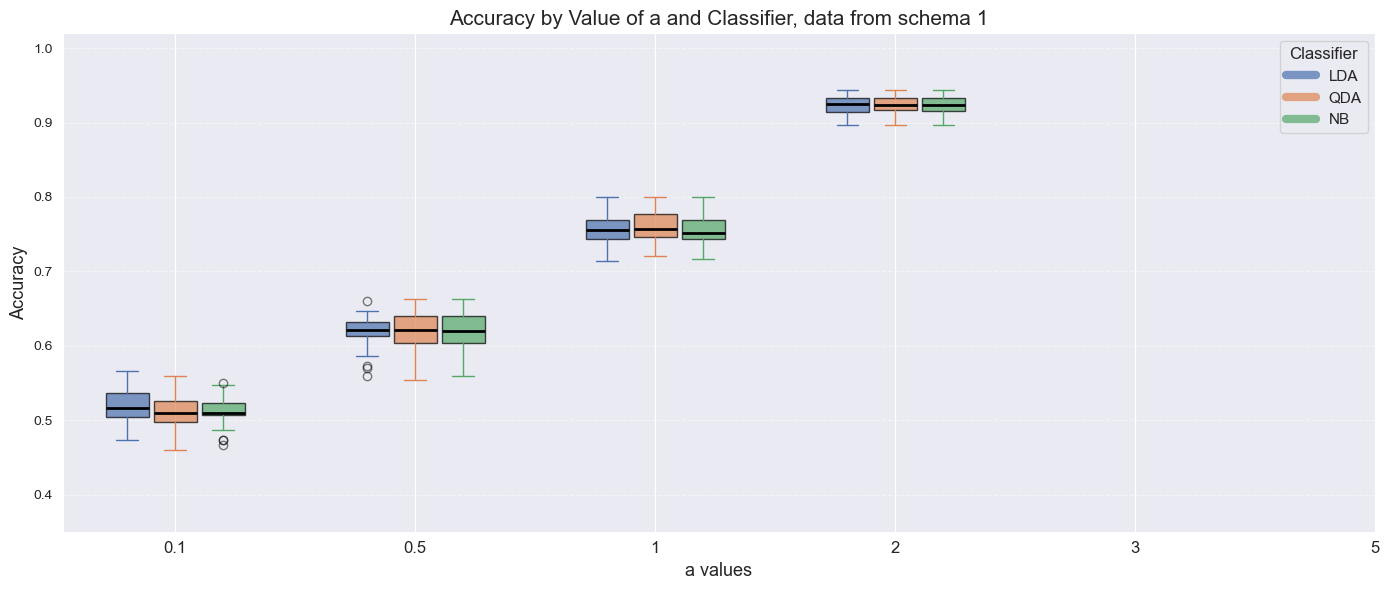

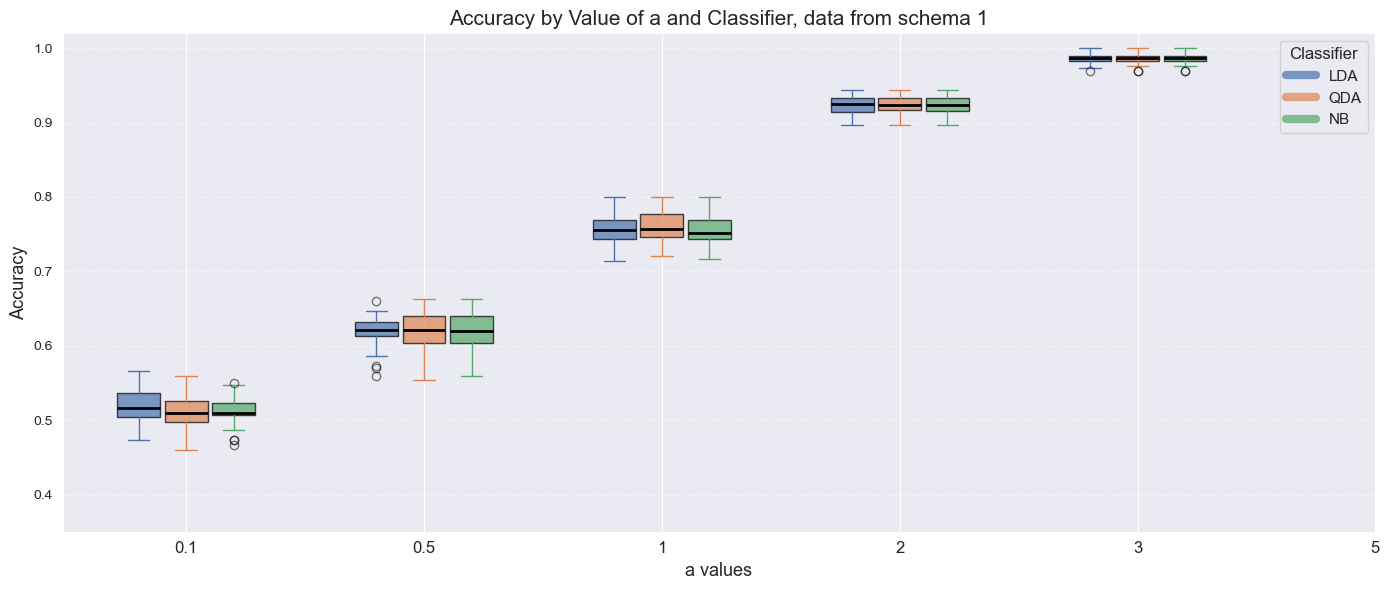

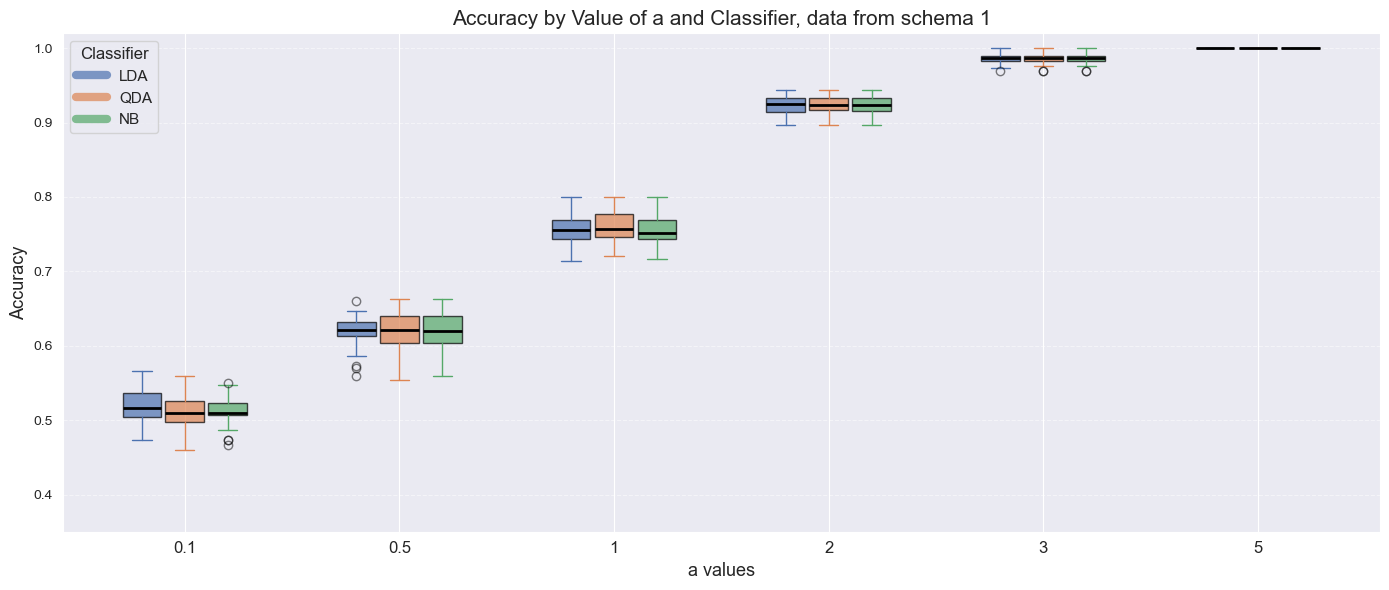

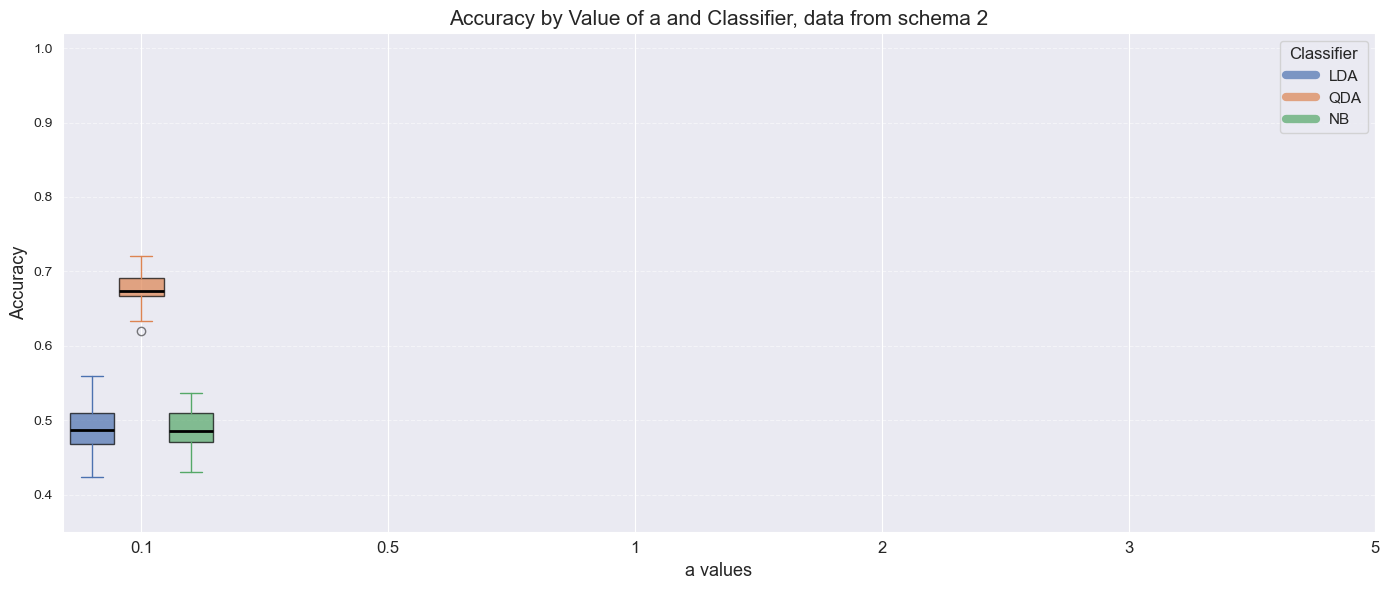

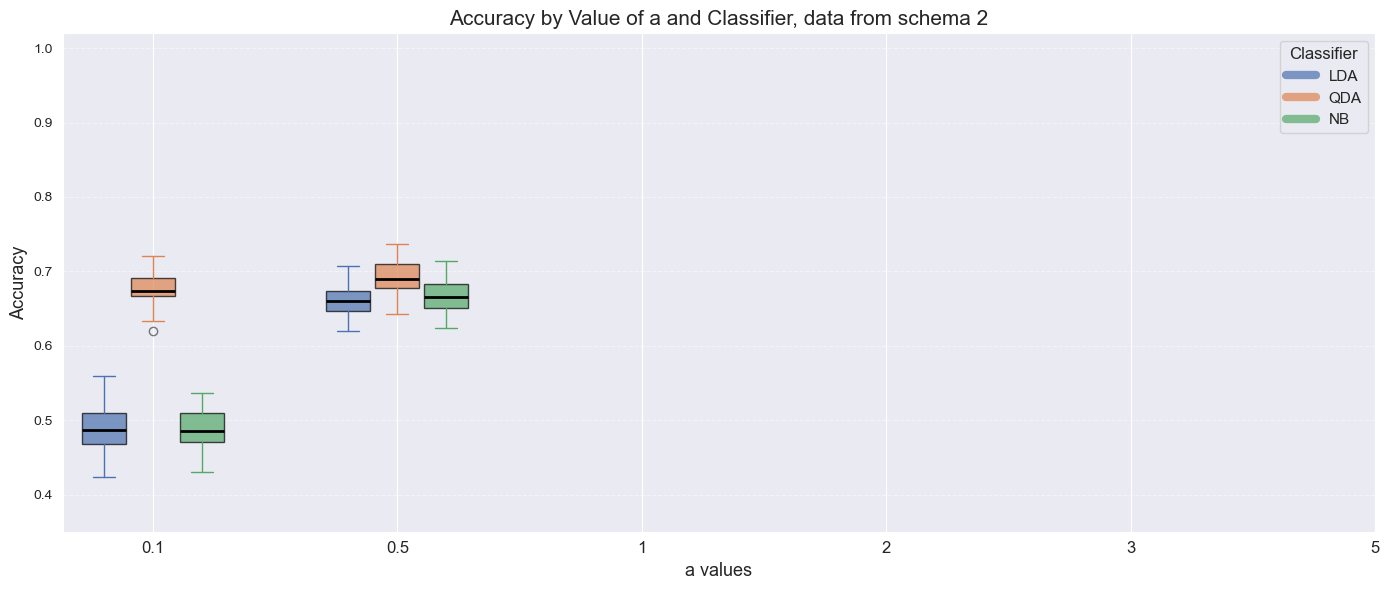

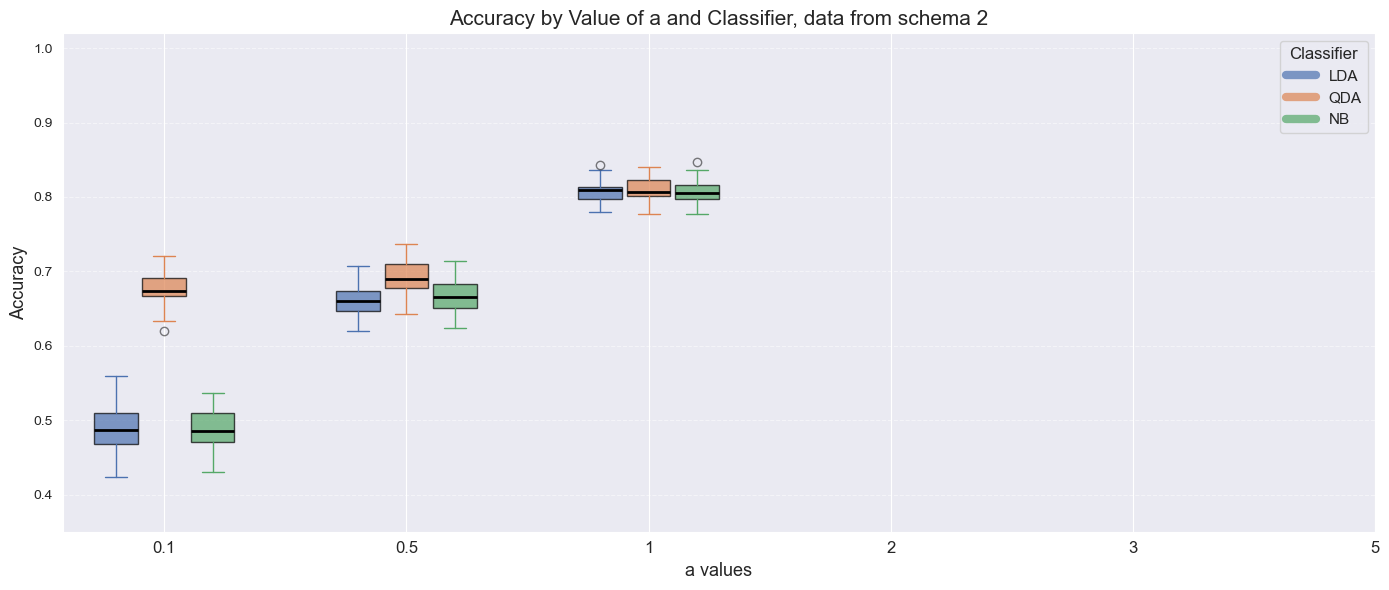

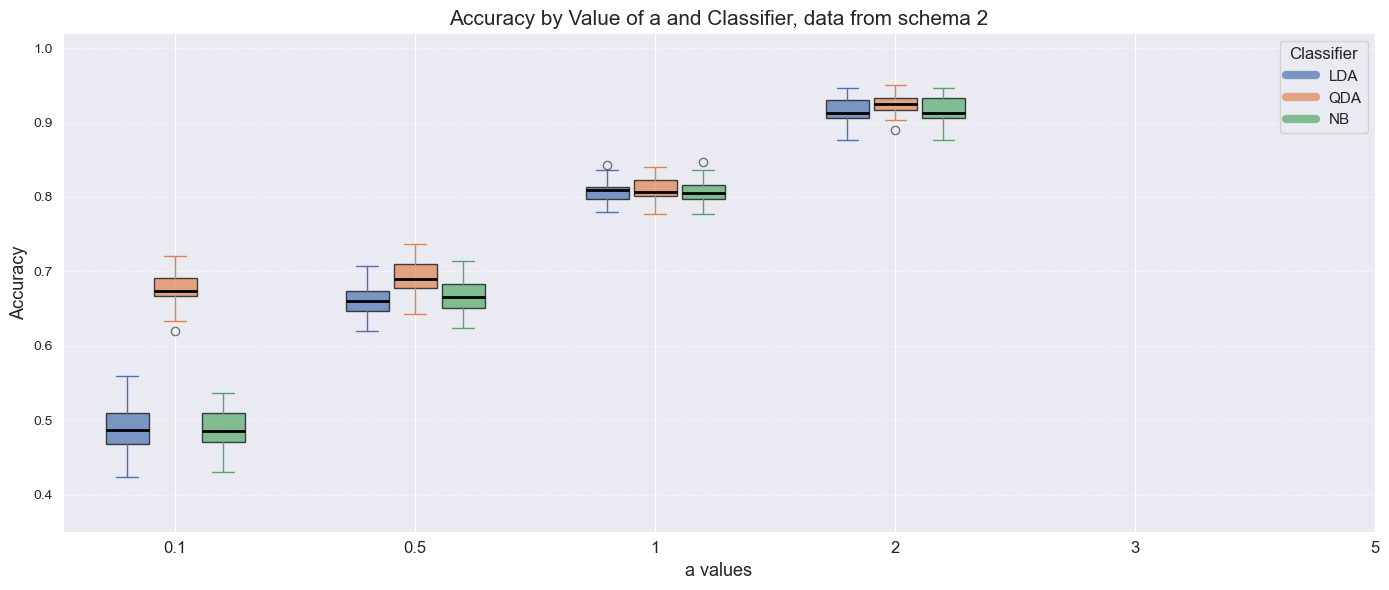

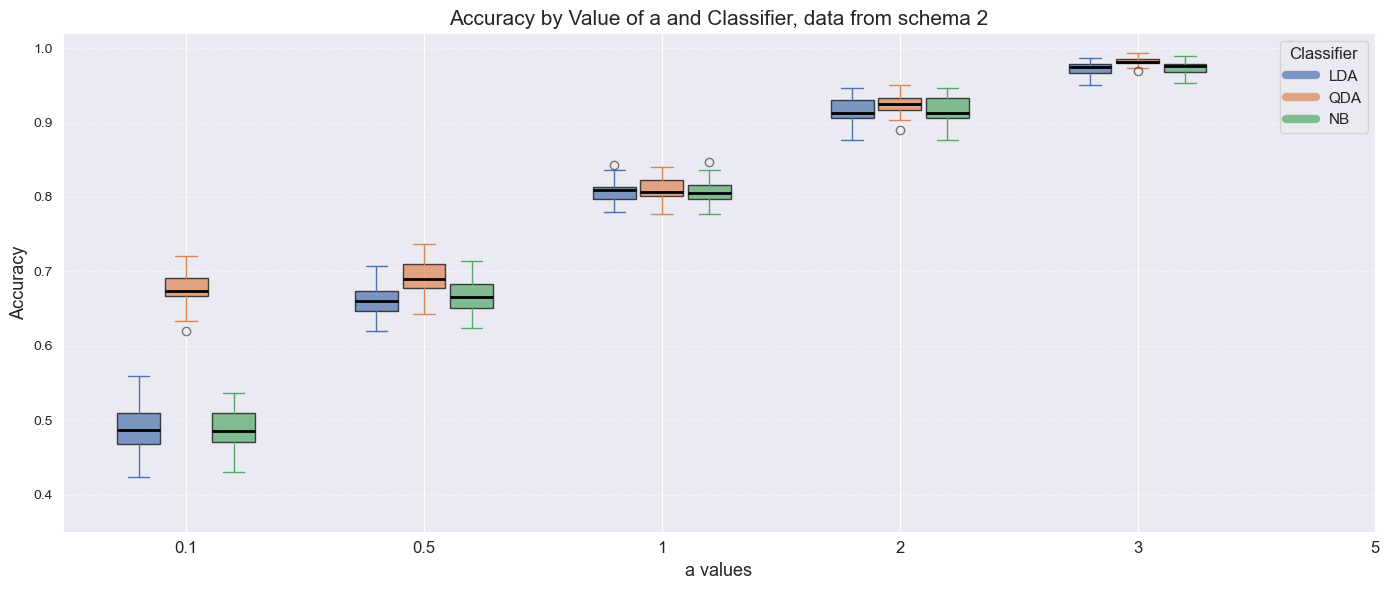

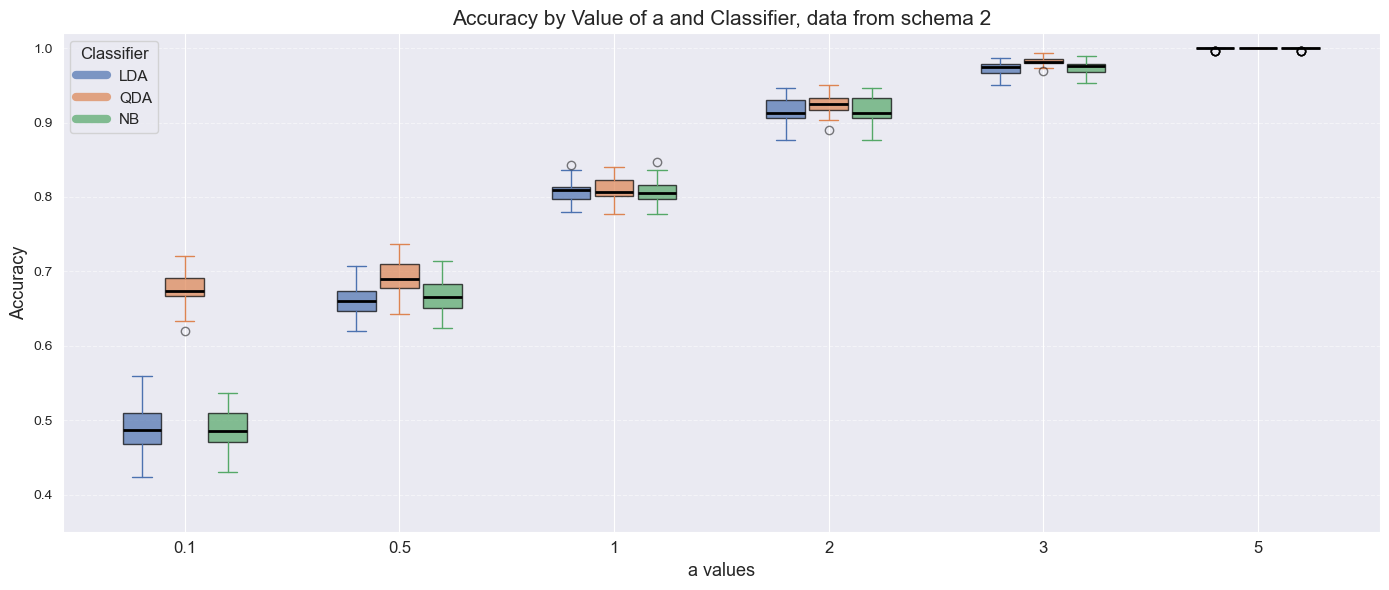

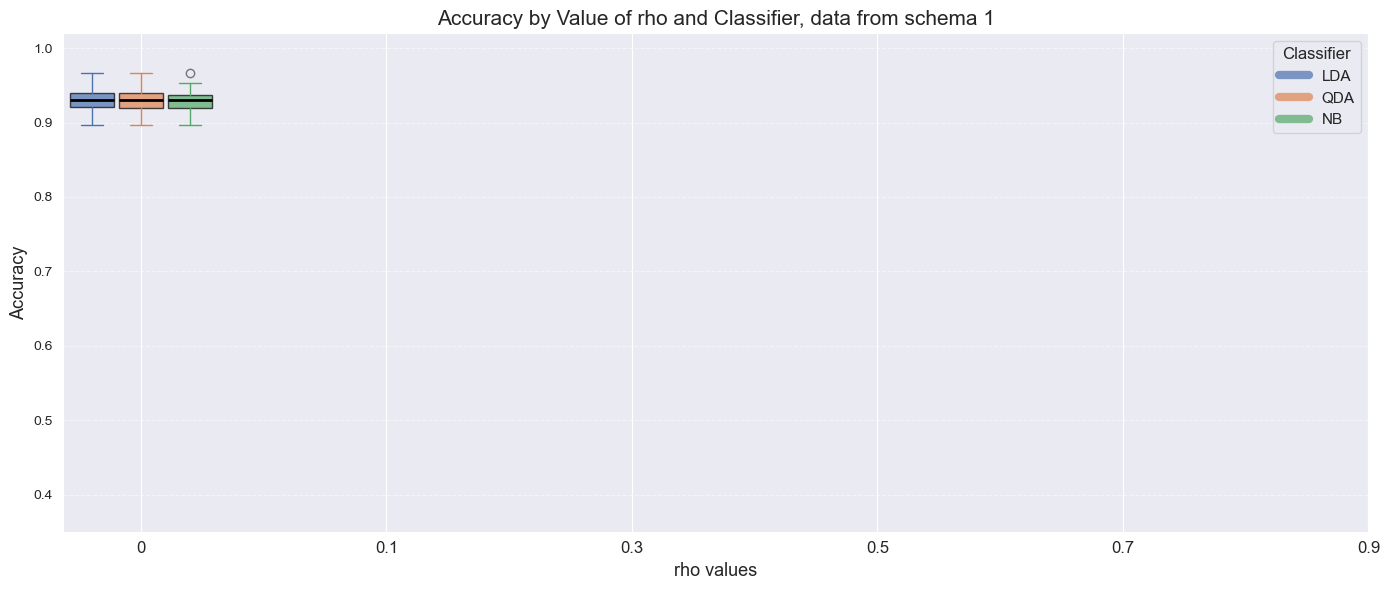

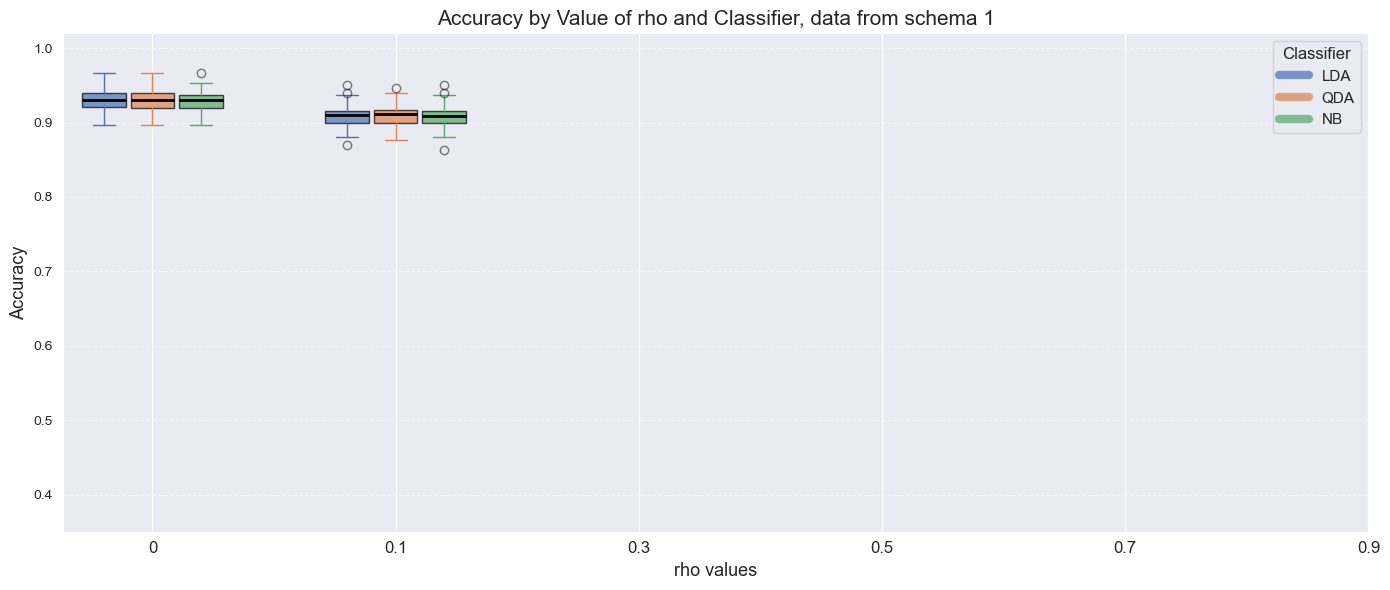

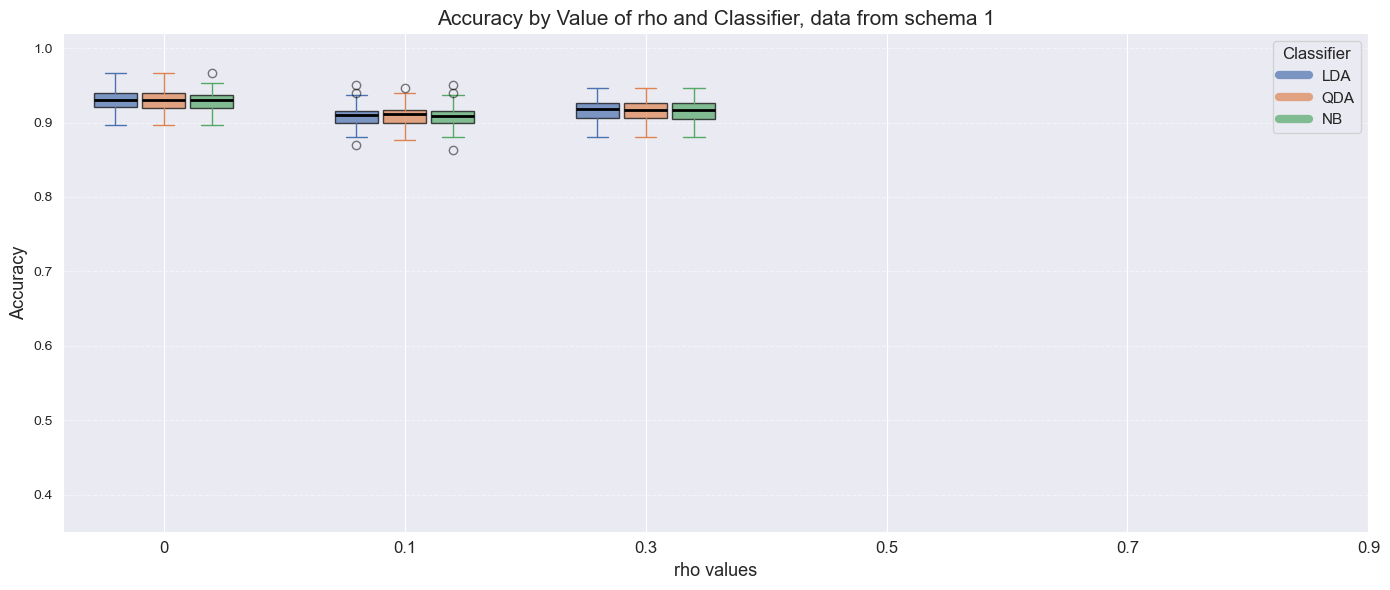

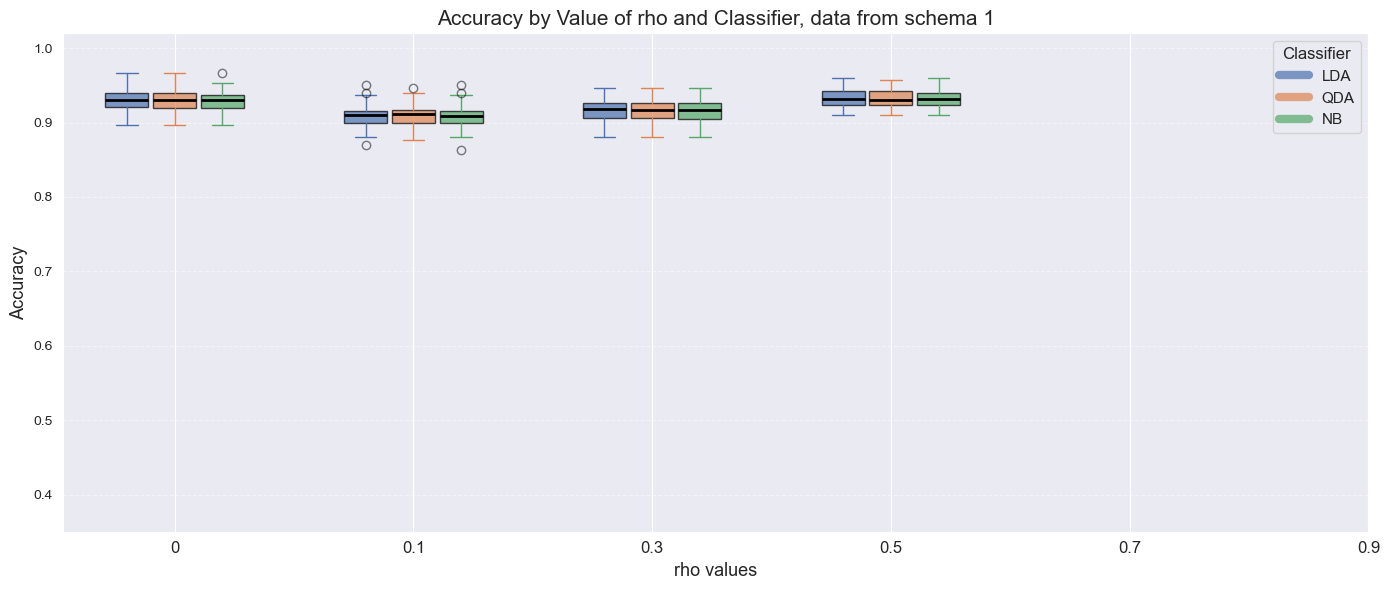

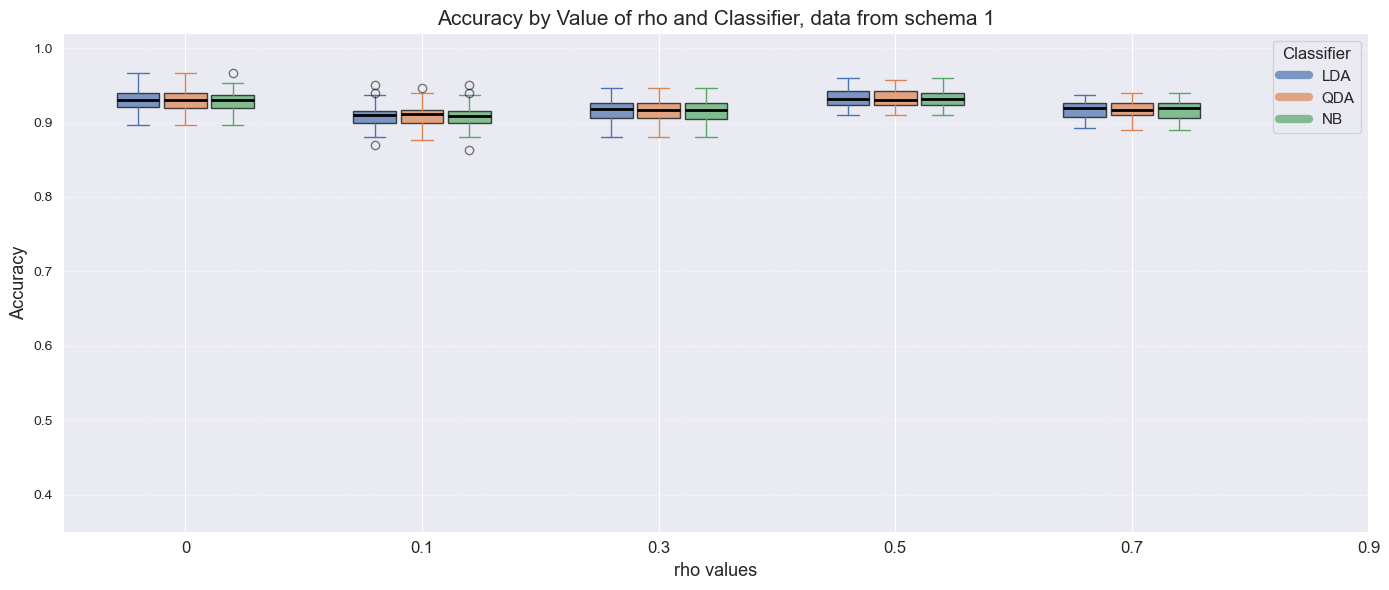

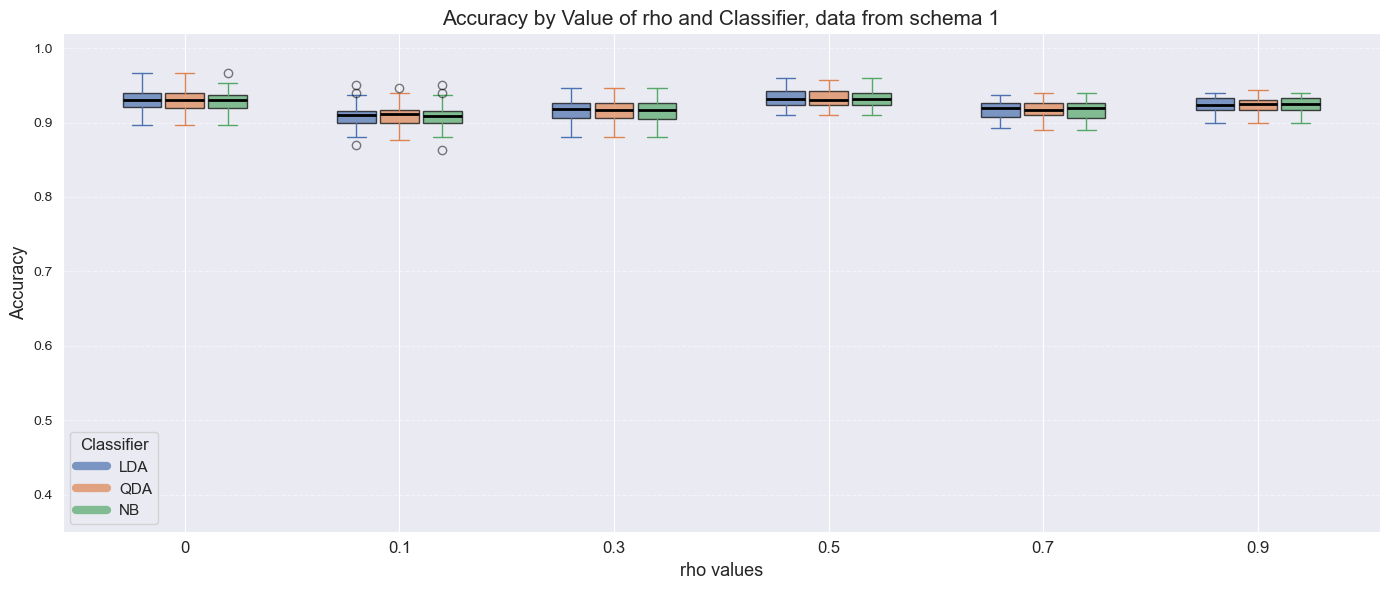

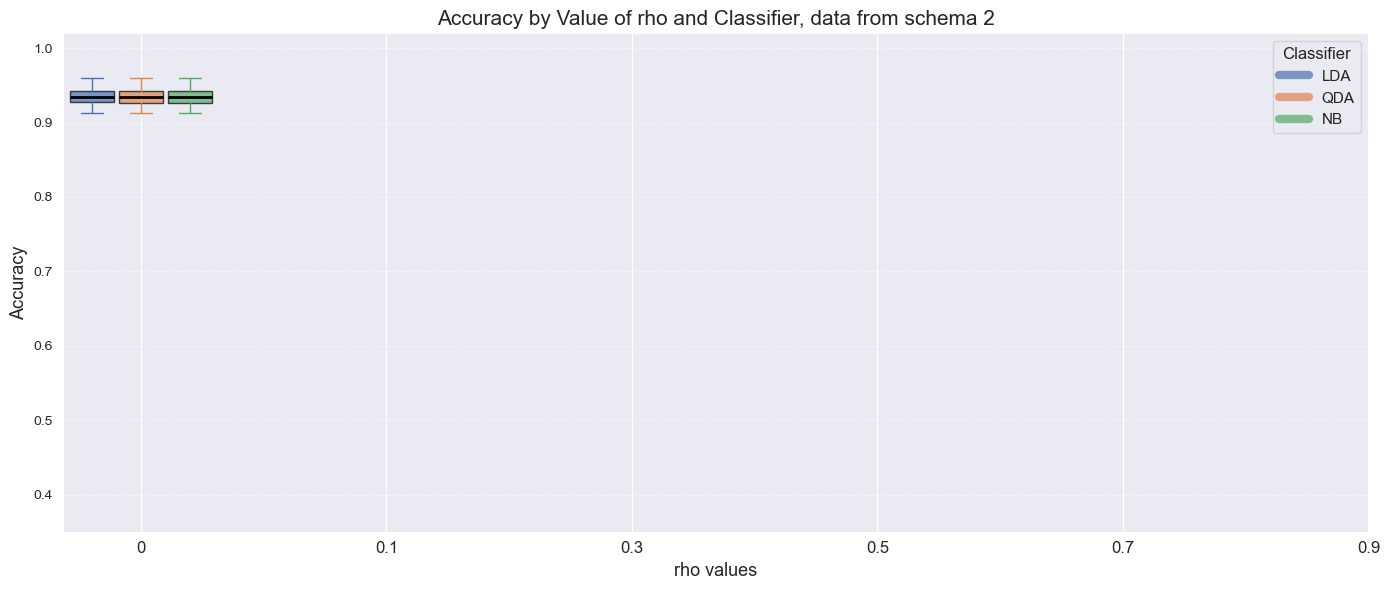

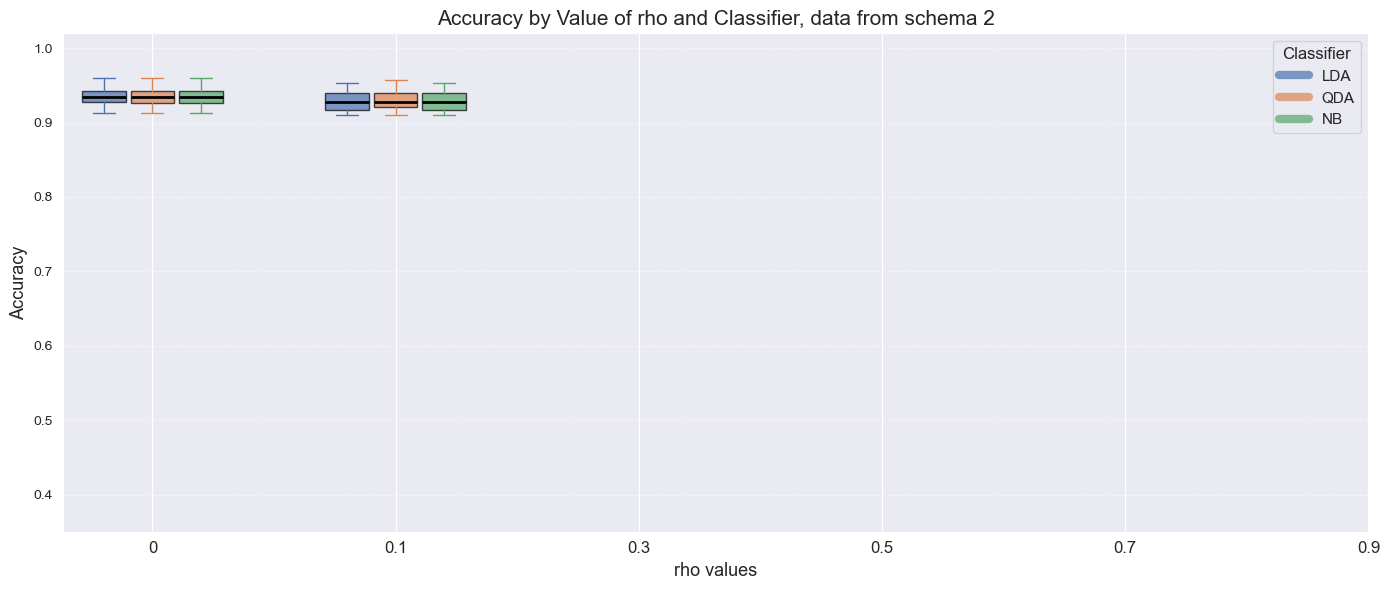

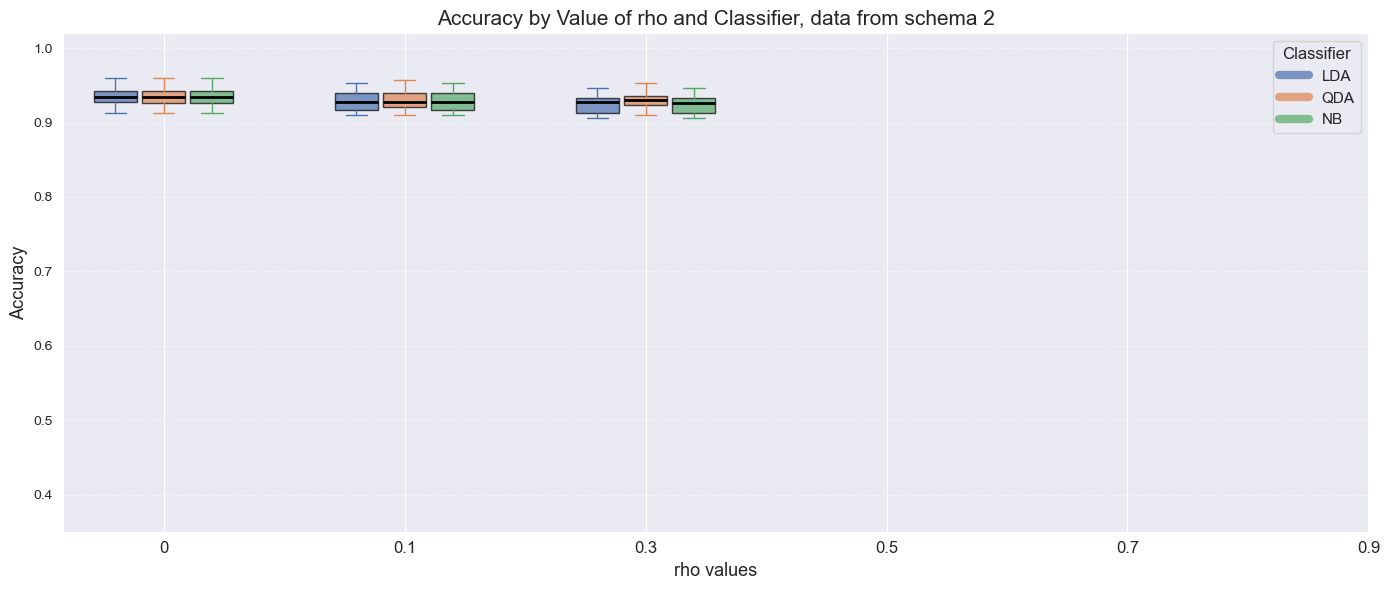

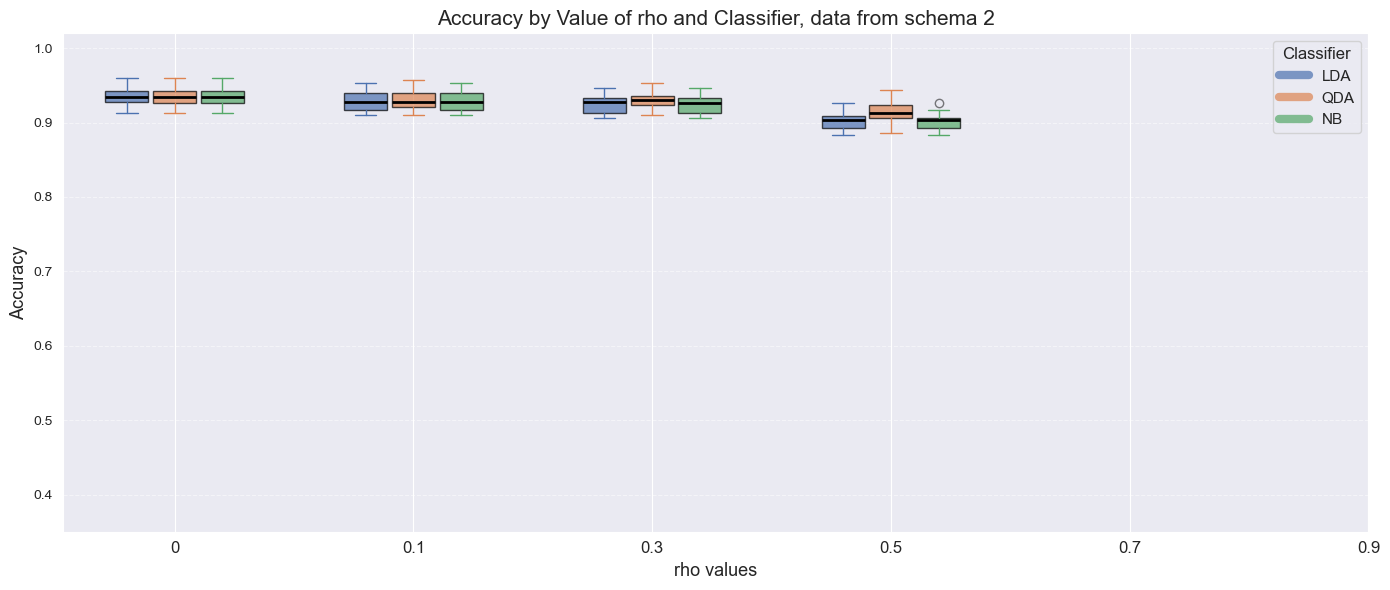

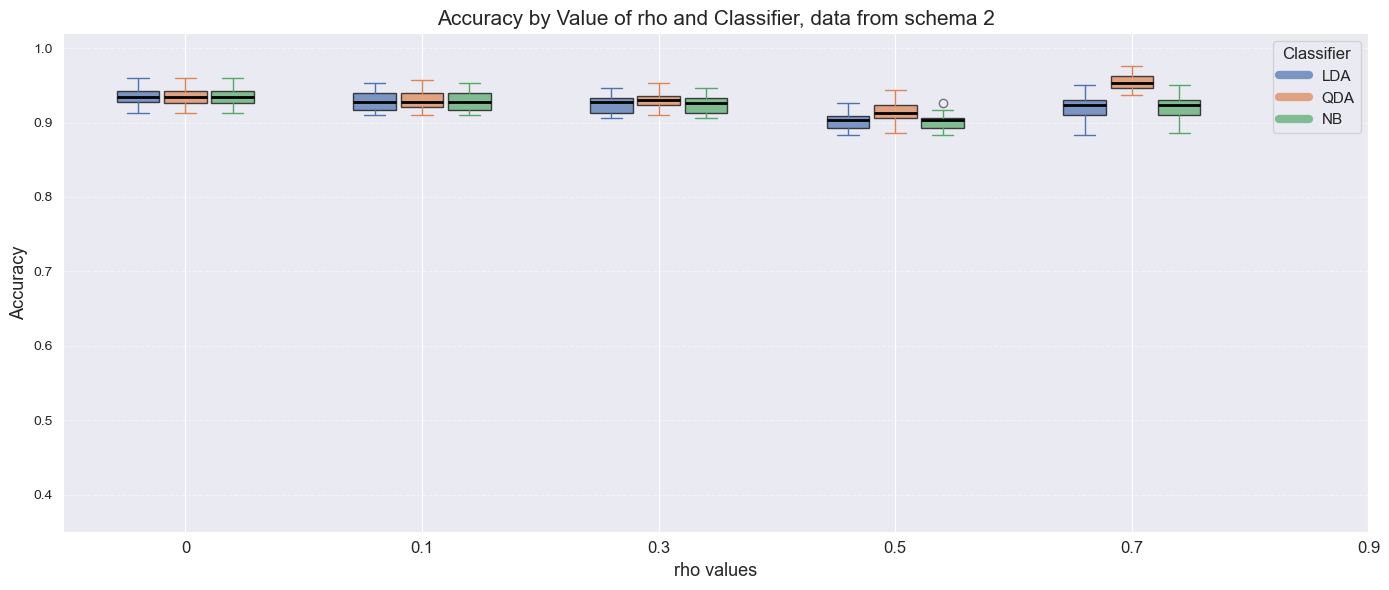

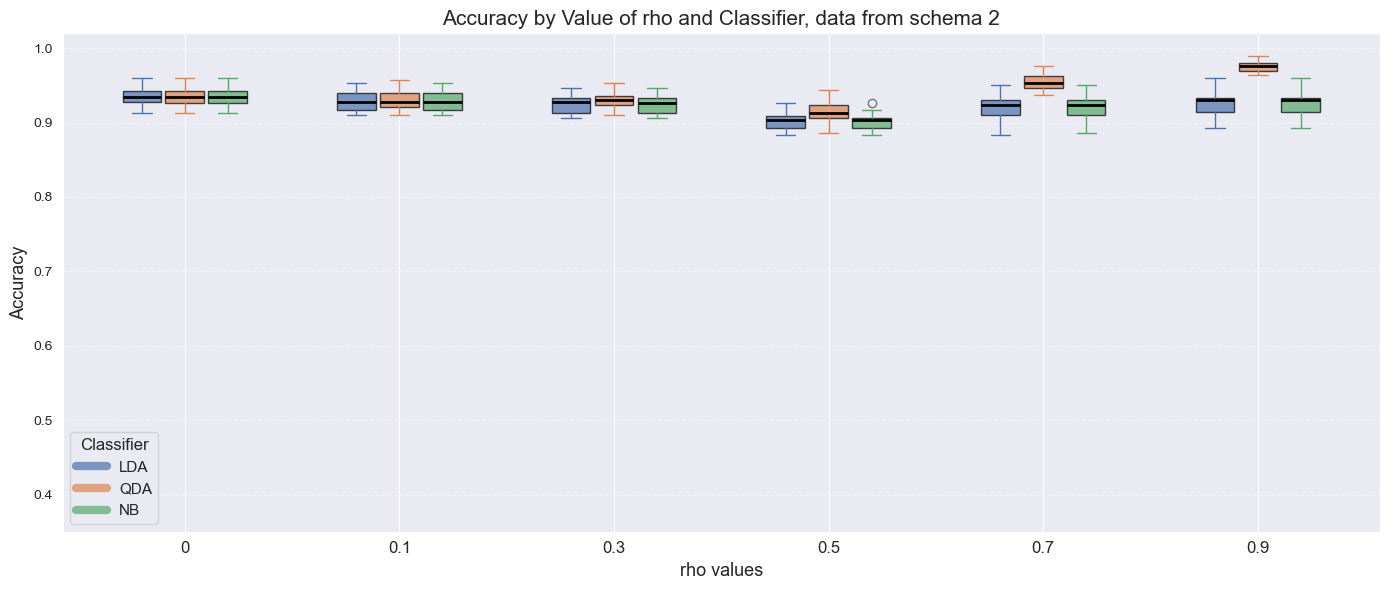

In [53]:
experiment_pipeline(1,"rho",0.5,"a",[0.1,0.5,1,2,3,5],"boxplot11v2.pdf")
experiment_pipeline(2,"rho",0.5,"a",[0.1,0.5,1,2,3,5],"boxplot12v2.pdf")
experiment_pipeline(1,"a",2,"rho",[0,0.1,0.3,0.5,0.7,0.9],"boxplot21v2.pdf")
experiment_pipeline(2,"a",2,"rho",[0,0.1,0.3,0.5,0.7,0.9],"boxplot22v2.pdf")



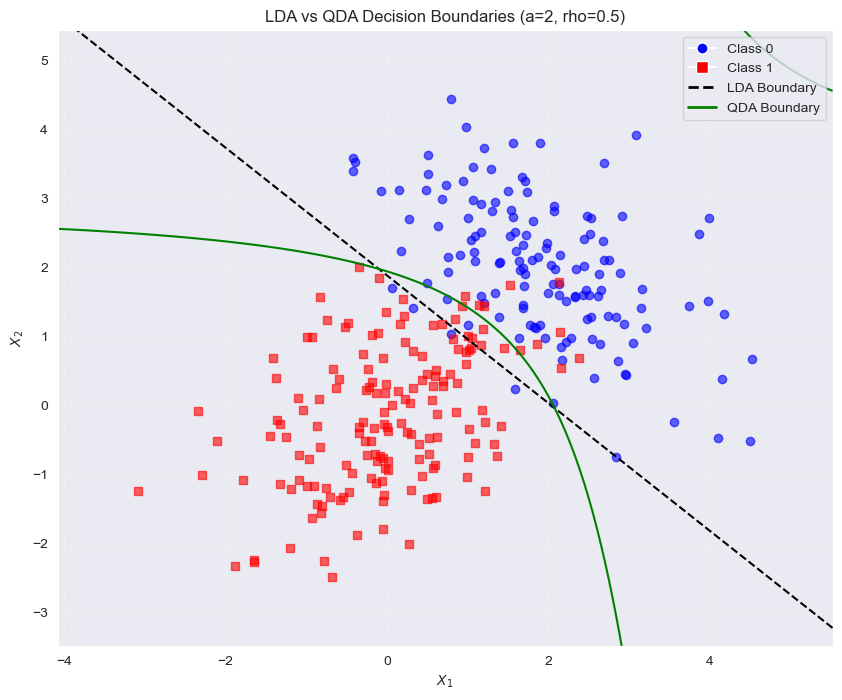

In [27]:
from matplotlib.lines import Line2D

# 1. Set Parameters
n, p, a, rho = 300, 2, 2, 0.5

# 2. Generate Data
data = simulation_set_creator.create_schema2(n, p, a, rho)
X = data[:, 0:2]
y = data[:, -1]

# 3. Fit Models
lda = LDA().fit(X, y)
qda = QDA().fit(X, y)

# 4. Create Grid for Decision Boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 5. Calculate Probabilities on Grid
Z_lda = lda.predict_proba(grid_points).reshape(xx.shape)
Z_qda = qda.predict_proba(grid_points).reshape(xx.shape)

# 6. Visualization
plt.figure(figsize=(10, 8))

# Scatter Plot
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', marker='o', alpha=0.6, label='Class 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', marker='s', alpha=0.6, label='Class 1')

# Draw Boundaries (where probability = 0.5)
plt.contour(xx, yy, Z_lda, levels=[0.5], colors='black', linestyles='--')
plt.contour(xx, yy, Z_qda, levels=[0.5], colors='green', linestyles='-')

# Custom Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=8, label='Class 0'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='red', markersize=8, label='Class 1'),
    Line2D([0], [0], color='black', lw=2, linestyle='--', label='LDA Boundary'),
    Line2D([0], [0], color='green', lw=2, linestyle='-', label='QDA Boundary')
]
plt.legend(handles=legend_elements, loc='best')

plt.title(f'LDA vs QDA Decision Boundaries (a={a}, rho={rho})')
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig(f"C:\\Users\\andrz\\Documents\\boxplot3.pdf", dpi=150)
plt.show()


In [50]:
import pandas as pd


def real_data_pipeline(setname, setpath, filename,target_col=-1, sep=None,map_target=False,target_mapper=None):
    accuracy_scores = {
        "LDA": [],
        "QDA": [],
        "NB": []
    }
    methods = ["LDA", "QDA", "NB"]
    seeds = np.random.randint(1, 1000000, 30)

    data = pd.read_csv(setpath, sep=sep)
    if target_col==-1:
        X = data.iloc[:, :-1].values
        y = data.iloc[:, -1].values
    else:
        X = data.iloc[:, target_col+1:].values
        y = data.iloc[:, target_col]
    if map_target:
        if target_mapper is None:
            print("Target mapping needed but mapper not provided")
            return
        y=y.apply(target_mapper)
        y=y.values
    for seed in seeds:

        x_train, x_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.3,
            random_state=seed,
        )
        for m in methods:
            # Assuming simulation_set_creator is defined globally
            own = simulation_set_creator.create_method(m)
            own.fit(x_train, y_train)
            y_test_hat = own.predict(x_test)
            accuracy_scores[m].append(accuracy_score(y_test, y_test_hat))

    # --- Simplified Plotting ---
    fig, ax = plt.subplots(figsize=(10, 6))

    # Prepare data as a list of arrays for the boxplot
    plot_data = [accuracy_scores[m] for m in methods]
    colors = ["#4C72B0", "#DD8452", "#55A868"]

    # Create the boxplot
    # patch_artist=True allows us to fill the boxes with color
    bp = ax.boxplot(plot_data, patch_artist=True, widths=0.6)

    # Apply styling to each box
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    # Style whiskers, caps, and medians for better visibility
    for element in ['whiskers', 'caps', 'medians']:
        plt.setp(bp[element], color='black', linewidth=1.5)

    # Customizing the axes
    ax.set_xticklabels(methods, fontsize=12)
    ax.set_ylabel("Accuracy", fontsize=13)
    ax.set_title(f"Accuracy Distribution on {setname} (30 Random Splits)", fontsize=15)

    # Grid and limits
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    # Automatically adjust Y-axis if data is high accuracy
    min_acc = min([min(accuracy_scores[m]) for m in methods])
    ax.set_ylim(max(0, min_acc - 0.05), 1.02)

    plt.tight_layout()
    plt.savefig(f"C:\\Users\\andrz\\Documents\\{filename}.pdf", dpi=150)
    plt.show()

    del accuracy_scores

C:\Users\andrz\AppData\Local\Temp\ipykernel_11136\40778837.py:23: RuntimeWarning: invalid value encountered in divide
  post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
C:\Users\andrz\AppData\Local\Temp\ipykernel_11136\1576351832.py:21: RuntimeWarning: invalid value encountered in divide
  post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
C:\Users\andrz\AppData\Local\Temp\ipykernel_11136\40778837.py:23: RuntimeWarning: invalid value encountered in divide
  post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
C:\Users\andrz\AppData\Local\Temp\ipykernel_11136\1576351832.py:21: RuntimeWarning: invalid value encountered in divide
  post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
C:\Users\andrz\AppData\Local\Temp\ipykernel_11136\40778837.py:23: RuntimeWarning: invalid value encountered in divide
  post=(cond1*self.prior)/(cond1*self.prior+cond0*(1-self.prior))
C:\Users\andrz\AppData\Local\Temp\ipykernel_11136\1576351832.py:21: RuntimeW

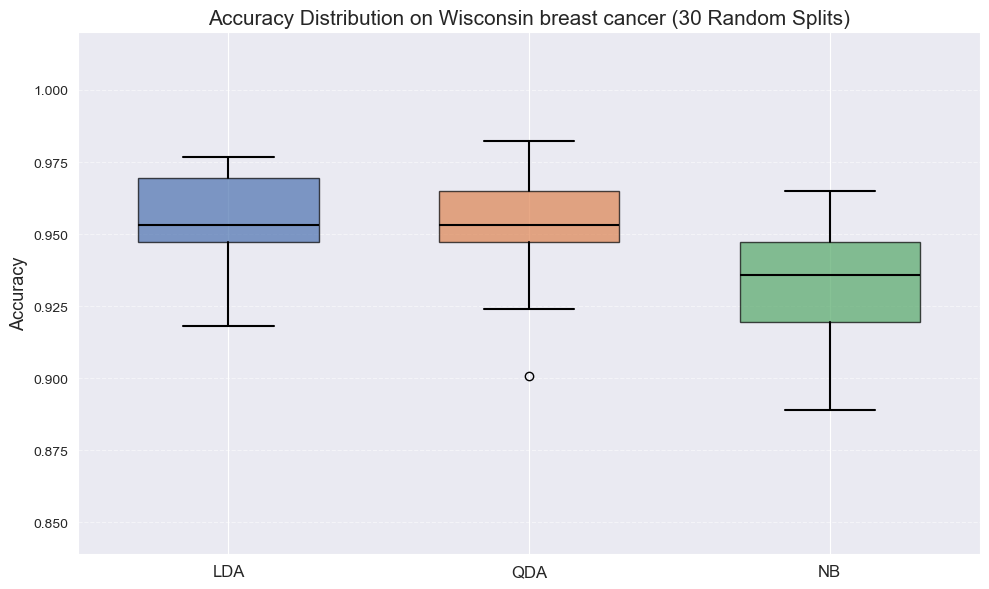

In [51]:
real_data_pipeline("Wisconsin breast cancer","C:\\Users\\andrz\\Downloads\\breast+cancer+wisconsin+diagnostic\\wdbc.data","wisconsin",target_col=1,sep=",",map_target=True,target_mapper=lambda x: 1 if x == 'M' else 0)

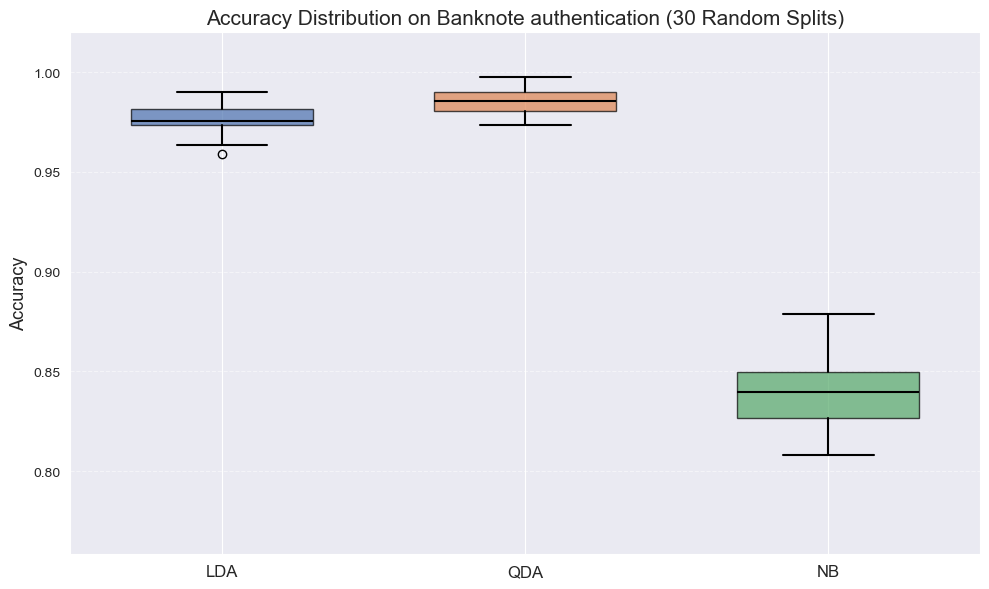

In [43]:
real_data_pipeline("Banknote authentication","C:\\Users\\andrz\\Downloads\\banknote+authentication\\data_banknote_authentication.txt","banknote",sep=",")